In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import sklearn


In [88]:
image_as_array = mpimg.imread('image-cropped-8x10.jpg')
image_as_array

array([[[254, 255, 255],
        [237, 238, 240],
        [231, 232, 234],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[254, 255, 255],
        [237, 238, 240],
        [231, 232, 234],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[254, 255, 255],
        [237, 238, 240],
        [230, 231, 233],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[253, 253, 253],
        [253, 253, 253],
        [254, 254, 254],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [89]:
image_as_array.shape

(503, 406, 3)

In [90]:
(h,w,c) = image_as_array.shape
reshaped_image = image_as_array.reshape(h*w,c)
reshaped_image.shape

(204218, 3)

(503, 406)


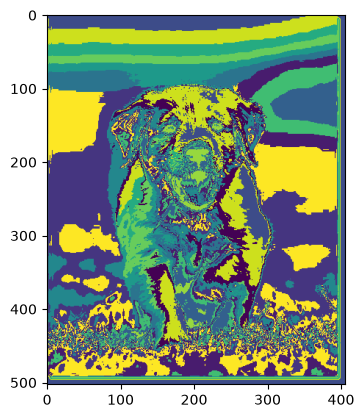

In [91]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=14, random_state=42)
labels = model.fit_predict(reshaped_image)


quantized_image = labels.reshape(h,w)
print(quantized_image.shape)

plt.imshow(quantized_image)


In [92]:
rgb_codes = model.cluster_centers_.round(0).astype(int)
rgb_codes

array([[216, 200, 183],
       [144, 126,  80],
       [178, 163, 110],
       [242, 240, 241],
       [ 93,  74,  40],
       [154, 138, 119],
       [194, 176, 139],
       [162, 155, 147],
       [197, 201, 206],
       [123, 100,  60],
       [180, 178, 177],
       [ 45,  32,  21],
       [228, 222, 218],
       [165, 148,  93]])

In [93]:
rgb_codes[labels]


array([[242, 240, 241],
       [242, 240, 241],
       [242, 240, 241],
       ...,
       [242, 240, 241],
       [242, 240, 241],
       [242, 240, 241]], shape=(204218, 3))

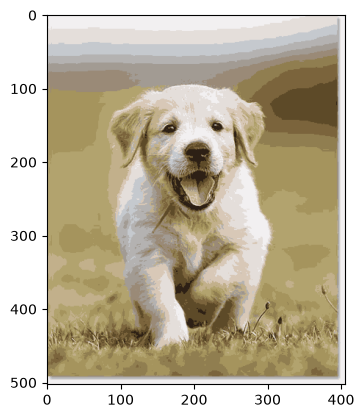

In [94]:
quantized_image = np.array(rgb_codes[labels].reshape(h,w,c))
plt.imshow(quantized_image)